In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)


In [30]:
def quantize_at_bitwidth(tensor, bits):
    q_min = -(2**(bits-1)) + 1
    q_max = (2**(bits-1)) - 1
    max_abs = np.abs(np.max(tensor))
    min_abs = np.abs(np.min(tensor))
    sym_scale = max(min_abs, max_abs)/q_max
    sym_quant_rounded = np.round((tensor / sym_scale))
    sym_quant_tensor_clip = np.clip(sym_quant_rounded, q_min, q_max)
    sym_quant_tensor = sym_quant_tensor_clip.astype(np.int16) # Here zero point = 0
    dequant_tensor = sym_quant_tensor * sym_scale
    return (sym_quant_tensor, dequant_tensor, sym_scale, q_min, q_max)


In [31]:
bit_widths = [8, 6, 4]
results = []
dequantized_list = []
for bits in bit_widths:
    q_tensor, dq_tensor, scale, q_min, q_max = quantize_at_bitwidth(tensor, bits)
    mae = np.mean(np.abs(tensor - dq_tensor))
    mse = np.mean((tensor - dq_tensor)**2)
    max_error = np.max(np.abs(tensor - dq_tensor))
    levels = q_max - q_min + 1
    results.append([bits, levels, scale, mae, mse, max_error])
    dequantized_list.append(dq_tensor)

In [33]:
for i in results:
    print(f'Bits :{i[0]}')
    print(f'Levels :{i[1]}')
    print(f'Scale :{i[2]}')
    print(f'MAE :{i[3]}')
    print(f'MSE :{i[4]}')
    print(f'Max error :{i[5]}')
    print("-----"*10)

Bits :8
Levels :255
Scale :0.018897637724876404
MAE :0.003700774861499667
MSE :2.1637999452650547e-05
Max error :0.007874011993408203
--------------------------------------------------
Bits :6
Levels :63
Scale :0.07741935551166534
MAE :0.015161285176873207
MSE :0.00036316324258223176
Max error :0.032258063554763794
--------------------------------------------------
Bits :4
Levels :15
Scale :0.34285715222358704
MAE :0.06714285910129547
MSE :0.00712245050817728
Max error :0.1428571492433548
--------------------------------------------------


In [9]:
dequantized_list

[array([[-1.7952756 , -0.9070866 ,  0.        ,  0.6992126 ,  1.4929134 ],
        [-2.4       , -0.3023622 ,  0.20787401,  1.096063  ,  2.0031495 ]],
       dtype=float32),
 array([[-1.7806451 , -0.92903227,  0.        ,  0.6967742 ,  1.4709678 ],
        [-2.4       , -0.30967742,  0.23225807,  1.083871  ,  2.0129032 ]],
       dtype=float32),
 array([[-1.7142857 , -1.0285715 ,  0.        ,  0.6857143 ,  1.3714286 ],
        [-2.4       , -0.34285715,  0.34285715,  1.0285715 ,  2.057143  ]],
       dtype=float32)]

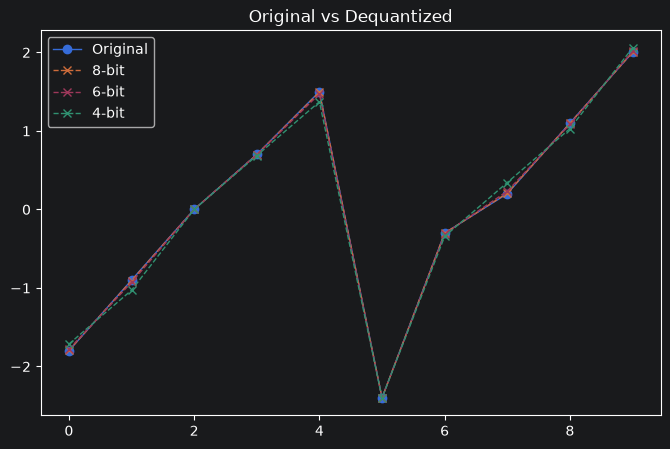

In [20]:
plt.figure(figsize=(8,5))
plt.plot(tensor.flatten(),
         marker='o',
         linewidth=1,
         label='Original')
for i, bits in enumerate(bit_widths):
    plt.plot(dequantized_list[i].flatten(),
             marker='x',
             linestyle='--',
             linewidth=1,
             label=f'{bits}-bit')
plt.title("Original vs Dequantized")
plt.legend()

plt.show()

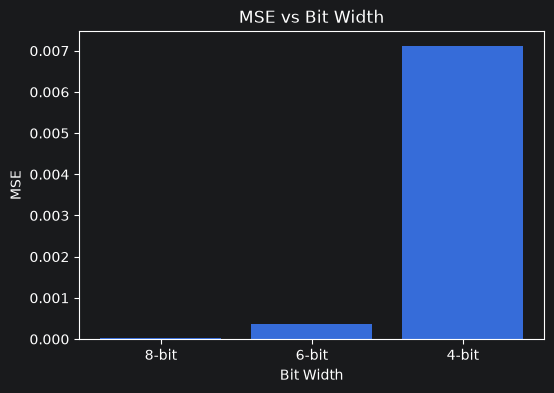

In [17]:
mse_values = [row[4] for row in results]
plt.figure(figsize=(6,4))
plt.bar(['8-bit','6-bit','4-bit'], mse_values)
plt.title("MSE vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("MSE")

plt.show()


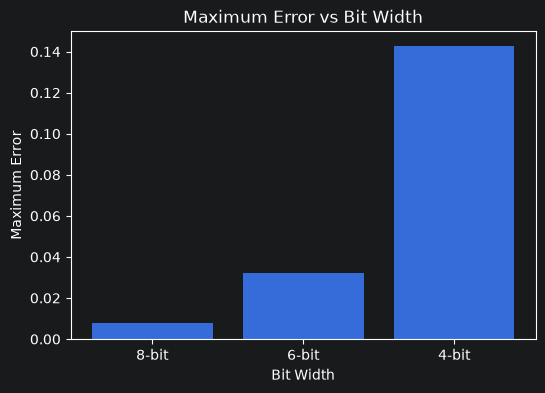

In [18]:
max_values = [row[5] for row in results]
plt.figure(figsize=(6,4))
plt.bar(['8-bit','6-bit','4-bit'], max_values)
plt.title("Maximum Error vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Maximum Error")

plt.show()